학습이란 훈련 데이터로부터 가중치 매개변수의 최적값을 자동을 획득하는 것이다. 그래서 이번 장에서는 신경망이 학습할 수 있도록 해주는 지표인 손실 함수를 소개한다. 이 손실 함수의 결과를 가장 작게 만드는 가중치 매개변수를 찾는 것이 목표이다. 그걸 돋는 함수의 기울기를 활용하는 경사법을 소개한다. 

## 데이터에서 학습한다.
데이터에서 학습한다는 것은 가중치 매개변수의 값을 데이터를 보고 자동으로 결정한다는 뜻이다.

### 데이터 주도 학습
기계 학습의 중심은 데이터이다. 기계학습에서는 데이터로부터 패턴을 찾으려 시도한다. 그러면 입력에서 특징(입력 데이터에서 본질적인 데이터를 정확하게 추출하도록 설계된 변환기)을 추출하고 그 패턴을 학습을 한다. 이미지에서는 특징은 벡터로 변환하는데 컴퓨터 비전에서는 SIFT. SURF, HOG 증의 특징을 사용하여 벡터로 변환하고 지도학습의 분류 기법인 SVM, KNN 등으로 학습한다. 하지만 모든 과정은 기계가 진행을 하지만 문제에 적합한 특징을 사용하지 않으면 좋은 결과를 얻지 못할 수도 있다. 하지만 신경망(딥러닝) 
방식은 이 마저도 기계간 스스로 학습한다.

### 훈련 데이터와 시험 데이터
기계학습 문제는 훈련 데이터와 시험 데이터로 나눠 학습과 실험을 수행해야한다. 훈련 데이터만으로 최적의 매개변수를 찾고 시험 데이터로 실력을 평가하는데 왜 이렇게 나누어야 하는가? 우리가 원하는 것은 범용적으로 사용할 모델이기 때문이다. 즉 보지 못한 데이터로도 문제를 올바르게 풀어낼 수 있는지 평가하기 위해서이다. 그리고 특정 데이터셋으로만 한다면 그 데이터 셋에만 지나치게 최적화된 상태인 오버피팅 될 수도 있다. 이를 피하는 것이 중요한 과제다

## 손실 함수
신경망 학습에서는 현재의 상태를 하나의 지표로 표현한다. 그 지표를 좋게 만드는 것은 가중치 매개변수의 값을 탐색하는 것이다. 이를 어떻게 해낼 수 있을까? 바로 손실 함수를 사용하는 것이다. 일반적인 예로 오차제곱합, 교차 엔트로피 오차를 사용한다.

### 오차 제곱합
신경망의 출력과 정답의 오차를 제곱하여 합하는 것을 오차제곱합이라 한다. 그리고 여기서 신경망의 출력은 소프트맥스 함수이다.

### 교차 엔트로피 오차
E = - sum(정답 * log(e, 출력)) 이라 할 수 있는데 정답 배열은 원-핫 인코딩 이므로 사실상 정답 레이블인 배열 인덱스의 출력에 로그 씌운 것에 -1 곱한 것과 같다. 그리고 로그 함수의 꼴을 보면 알 수 있지만 정답에 해당하는 출력이 커질 수록 0에 다가간다. 왜냐하면 log(1) = 0 이니까

### 미니배치 학습
기계학습은 훈련 데이터에 대한 손실 함수의 값을 구하고 그 값을 최대한 줄여주는 매개변수를 찾습니다. 그런데 이러면 모든 훈련 데이터를 대상으로 손실 함수를 구해야 하는데 방금의 손실 함수들은 훈련 데이터 하나에 대한 손실 함수만 생각했기에 모두에 대한 손실 함수의 합을 구하는 방법을 생각해보자.

In [5]:
# mnist 데이터 셋 불러오기
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


In [7]:
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

In [ ]:
def cross_entry_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

In [ ]:
# 함수 테스트용 임의의 예측값 y 생성 (모양: 10 x 10)
dummy_y = np.random.rand(10, 10)

# 값들을 확률(총합 1)처럼 만들기 위한 정규화 (생략해도 모양만 맞아서 돌아가긴 합니다)
dummy_y = dummy_y / np.sum(dummy_y, axis=1, keepdims=True)

loss = cross_entry_error(dummy_y, t_batch)
print(loss)


2.5767518781913386


### 왜 손실 함수를 설정하는가?
정확도를 라는 확실한 지표 대신에 왜 손실 함수의 값을 사용할까? 그 이유는 미분에 있다. 최적의 매개변수를 탐색할 때 손실 함수의 값을 작게 하는 값을 찾는다. 이때 매개변수의 미분(기울기)를 계산하고 그 미분 값을 단서로 매개변수의 값을 갱신하는 것이다.  
예를 들어 어떤 가중치 매개변수에 집중해보자. 이때 가중치 매개변수의 손실함수의 미분이란 가중치 매개변수의 값을 아주 조금 변화 시킬 때의(앱실론의 변화) 손실 함수의 변화를 알 수 있다. 그 값이 음수면 가중치 매개변수를 양의 방향으로 변화시켜서 손실 함수의 값을 줄일 수 있다. 그리고 0이면 어느쪽으로 움직여도 손실함수의 값은 줄어들지 않는다.  
이런 이유로 정확도를 지표 삼지 않는 것인데 정확도를 지표로 삼는다면 미분 값이 대부분의 장소에서 0이 되어 매개변수를 갱신할 수 없다. 그렇다면 이러한 이유는 또 무엇인가? 정확도는 미묘한 변화에 거의 반응을 보이지 않고 있더라고 그 값이 불연속적으로 갑자기 변화한다. 그래서 계단 함수를 활성화 함수로 사용하지 않는 이유와 같다. 

## 수치 미분
경사법에서는 기울기 값을 기준으로 나아갈 방향을 정한다. 기울기와 미분의 성질을 알아보자.

### 미분
수학 시간에서 배운 미분을 파이썬으로 구현하자.

In [ ]:
def _numerical_diff(f, x):
    h = 1e-50
    return (f(x + h) - f(x)) / h

여기서 가능한 작은 값을 넣고 싶어 h = 1e-50이라는 작은 값을 이용했다. 하지만 이 방식은 반올림오차를 발생 시킨다. 반올림오차는 작은 값이 생략되어서 계산 결과에 오차를 생기게 하는 것이다. 그래서 h = 1e-4로 바꾸자.  
두 번째 문제는 차분에 있다. 진정한 미분은 그 점에 해당하는 접선이지만 지금의 형태는 그저 x+h, x와의 기울기일 뿐이다. 그래서 오차가 발생하는데 이런 오차를 줄이기 위해서 (x+h), (x-h)일 때의 차분을 계산하는 방법을 쓴다. 중심을 전후의 차분을 계산하는 것이라서 중심, 중앙 차분이라고 한다. 앞서 구현한 것은 전방 차분이다.  
그래서 개선한 수치 미분 함수는 아래와 같다.

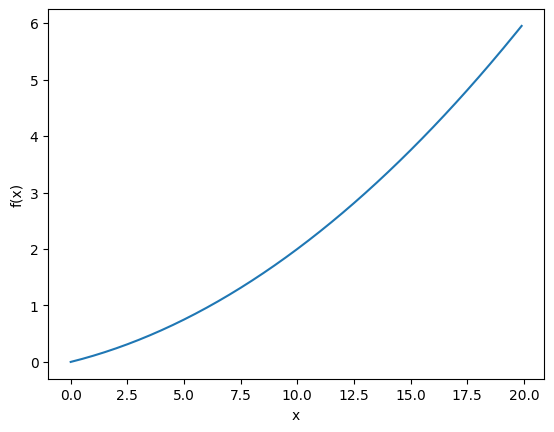

0.1999999999990898


In [1]:
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h) - f(x-h)) / (2 * h)

def f1(x):
    return .01 * x**2 + .1*x

import numpy as np
import matplotlib.pylab as plt
x = np.arange(.0, 20.0, .1)
y = f1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

print(numerical_diff(f1, 5))

### 편미분
아래와 같은 변수가 2개인 함수가 있다고 하자. 물론 x는 넘파이 배열이다. 이때 x_0 = 3, x_1 = 

In [2]:
def f2(x):
    return x[0]**2 + x[1]**2

def f_t0(x0):
    return x0 * x0 + 4.0**2.0

numerical_diff(f_t0, 3)

6.00000000000378

## 기울기
앞에서 편미분을 할 때 변수별로 따로 계산 했는데 동시에 하는 방법이 없을까? 모든 변수의 편미분을 벡터로 정리하면 된다. 이를 기울기(gradient) 라고 한다. 앞으로 기울기보다 그래디언트로 작성할 것이다.

In [ ]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = x[idx]

        x[idx] = tmp_val + h
        fxh1 = f(x)

        x[idx] = tmp_val - h
        fxh2 = f(x)
ㄴ
        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val

    return grad

numerical_gradient(f2, np.array([3.0, 4.0]))

array([6., 8.])

그럼 기울기가 의미하는 바는 무엇일까? 기울기는 함수의 가장 낮은 장소를 가리키지만 사실은 각 지점에서 낮아지는 방향을 가리킨다. *** 정확하게 기울기가 가리키는 쪽은 각 장소에서 함수의 출력 값을 가장 크게 줄이는 방향이다. ***  
### 경사법 (경사 하강법)
신경망은 최적의 매개변수를 학습시에 찾아야 하고 손실 함수가 최솟값이 될 때의 값을 찾아야 하지만 손실함수는 복잡하여 최솟값이 되는 포인트를 짐작할 수 없다. 이때 사용하는 방법이 경사 하강법이다. 그러나 기울기가 함수 값을 낮추는 방안을 제시만 할 뿐 실제 가리키는 곳에 최솟값이 있는지 방향이 정말 나아갈 방향인지는 보장하지 않는다.  
경사법은 현 위치에서 기울어진 방향으로 일정 거리만큼 이동하고 이동한 곳에서도 기울기를 구하고 또 이동하고를 반복하여 함수 값을 줄이는 것이다. 다음과 같이 구현할 수 있다.

In [4]:
def gradient_descent(f, init_x, lr=.01, step_num=100):
    x = init_x
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

init_x = np.array([-3.0, 4.0])
gradient_descent(f2, init_x=init_x, lr=.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

이번 함수의 결과는 0의 가깝게 나왔다. 경사법을 이용해서 정확한 결과를 얻은 것이다. 이때 학습률(lr)이 너무 크면 발산하고 너무 작으면 거의 갱신되지 않은채로 끝난다. 그래서 학습률을 적절히 설정해야 하고 이와 같은 매개변수를 하이퍼파라미터라고 한다.  

### 신경망에서의 기울기
가중치 매개변수에 대한 손실함수의 기울기를 구해보자. 어떤 가중치가 2x3 행렬이라면 그의 경사는 각 원소에 대하여 편미분 한 것이다. 이를 구하는 것을 코드로 구현하면  

In [ ]:
import numpy as np
from functions import *

class simpleNet:
    def __init__(self):
        self.W = np.random.rand(2, 3) # 정규분포로 초기화
    
    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entry_error(y, t)

        return loss

: 